In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
df = pd.read_csv("wbes_sintetico.csv")
df.head()

,employees,firm_age_years,training,access_finance,exporter,digital_payments,competition_level,sector,sales_annual_usd,labor_productivity_usd_per_employee,successful
0,13.0,10.0,1.0,1.0,0,1,Media,Manufactura,42879.327130,5374.714150,1
1,9.0,6.0,0.0,0.0,0,1,Baja,Servicios,54570.897174,4728.282631,0
2,15.0,10.0,0.0,0.0,1,1,Baja,Servicios,56311.260030,3104.627628,0
3,25.0,12.0,1.0,0.0,1,1,Baja,Servicios,93419.359675,3129.017055,1
4,9.0,9.0,0.0,0.0,0,0,Baja,Manufactura,24608.889361,2824.645056,1


In [29]:
df.replace(" ", np.nan, inplace=True) 
df.dropna(inplace=True)

In [32]:
x = df[['employees', 'firm_age_years']] 
y = df['successful']

In [33]:
# ORDEN CORRECTO: X_entrenamiento, X_prueba, y_entrenamiento, y_prueba
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0)

In [34]:
# Crear el objeto
log = LogisticRegression()

# Entrenar
log.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Precisión del modelo (Accuracy): 0.58


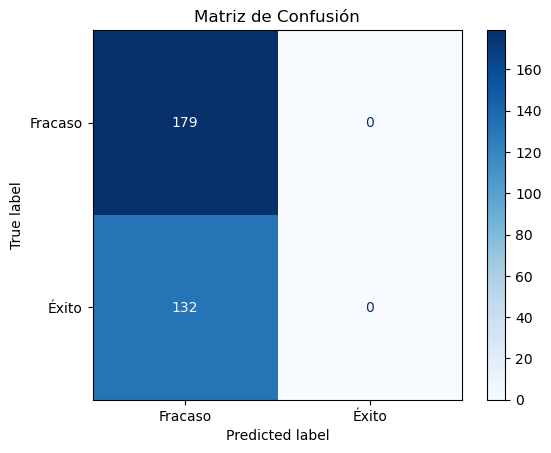

In [37]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Realizar predicciones
y_pred = log.predict(X_test)

# 2. Calcular Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión del modelo (Accuracy): {accuracy:.2f}")

# 3. Mostrar Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fracaso', 'Éxito'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión")
plt.show()

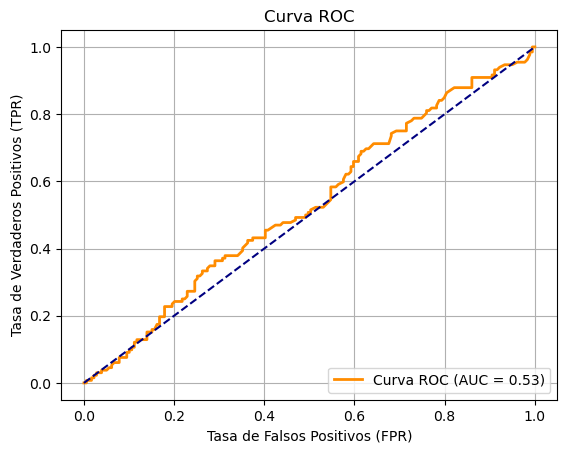

In [38]:
from sklearn.metrics import roc_curve, roc_auc_score

# Para la curva ROC necesitamos las PROBABILIDADES, no las predicciones finales
y_probs = log.predict_proba(X_test)[:, 1]

# Calcular la curva
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

# Graficar
plt.plot(fpr, tpr, label=f"Curva ROC (AUC = {auc:.2f})", color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # Línea de azar
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [39]:
# Ver la importancia de cada variable
for col, coef in zip(X.columns, log.coef_[0]):
    print(f"Variable: {col} | Coeficiente: {coef:.4f}")

Variable: employees | Coeficiente: 0.0077
Variable: firm_age_years | Coeficiente: 0.0066
